#Surya Prasad M
#24BAD119

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.xls')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Check missing values
print(df.isnull().sum())

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Optional: include Age
# X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


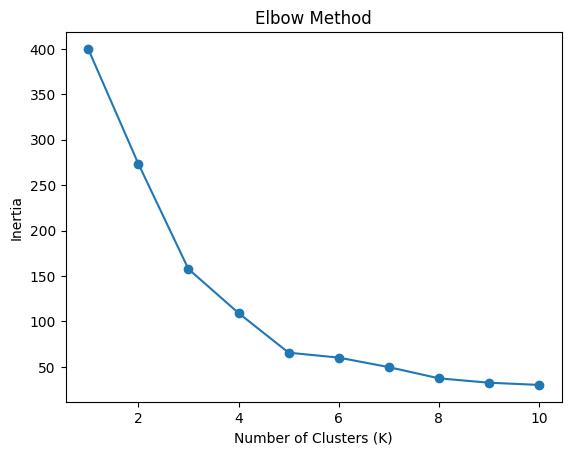

In [5]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters_kmeans

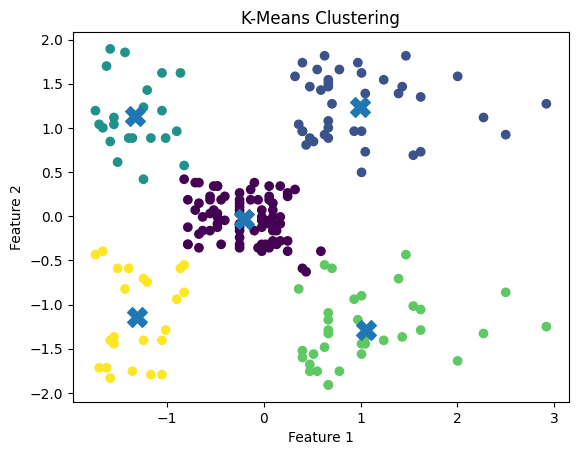

In [7]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [12]:
print("K-Means Inertia:", kmeans.inertia_)
print("K-Means Silhouette Score:", silhouette_score(X_scaled, clusters_kmeans))
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))

K-Means Inertia: 65.56840815571681
K-Means Silhouette Score: 0.5546571631111091
                CustomerID        Age  Annual Income (k$)  \
KMeans_Cluster                                              
0                86.320988  42.716049           55.296296   
1               162.000000  32.692308           86.538462   
2                23.090909  25.272727           25.727273   
3               164.371429  41.114286           88.200000   
4                23.000000  45.217391           26.304348   

                Spending Score (1-100)  GMM_Cluster  
KMeans_Cluster                                       
0                            49.518519     0.000000  
1                            82.128205     1.000000  
2                            79.363636     1.909091  
3                            17.114286     2.828571  
4                            20.913043     4.000000  


In [10]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

clusters_gmm = gmm.predict(X_scaled)
probabilities = gmm.predict_proba(X_scaled)

df['GMM_Cluster'] = clusters_gmm

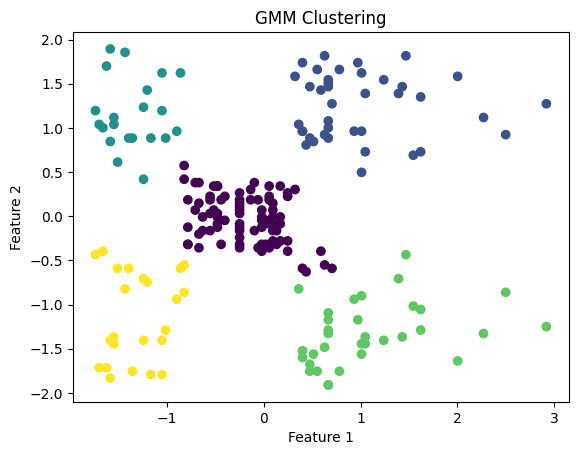

In [13]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.title('GMM Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [14]:
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("GMM Silhouette Score:", silhouette_score(X_scaled, clusters_gmm))

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
GMM Silhouette Score: 0.5536892843811245


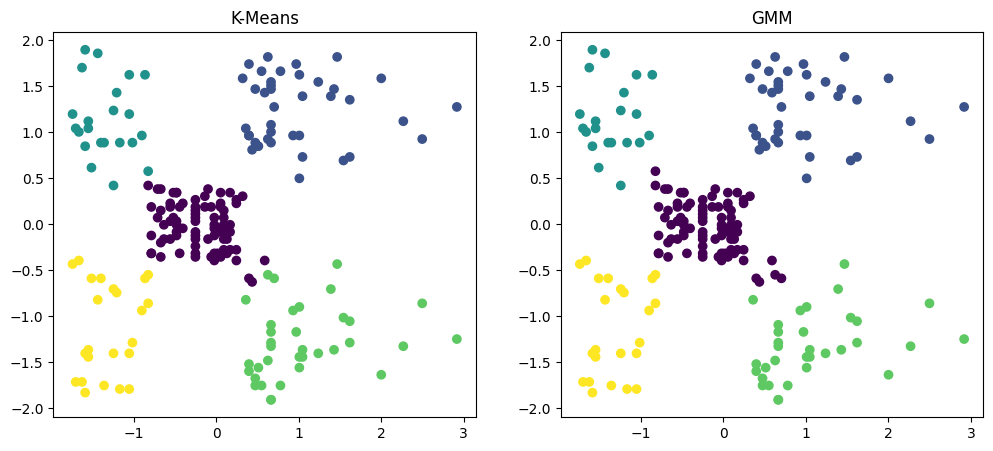

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_kmeans)
plt.title('K-Means')

plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_gmm)
plt.title('GMM')

plt.show()

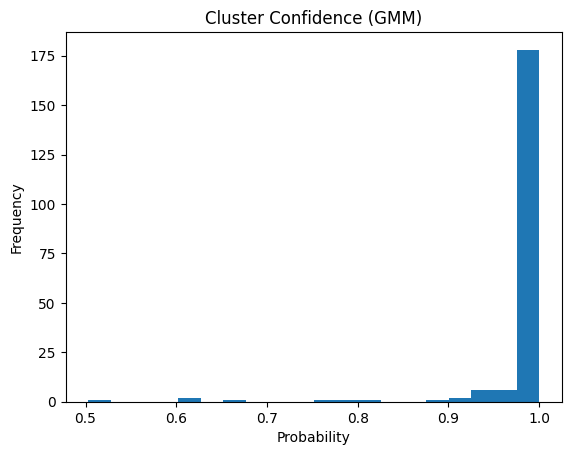

In [16]:
plt.hist(probabilities.max(axis=1), bins=20)
plt.title('Cluster Confidence (GMM)')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()